In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

#### Loading Data-Table

In [2]:
tab = Table.read("C:/Users/Ruben/Desktop/All_candidates_200pc_noparallaxovererror.vot")

#### What subsample can be expected to be volume-complete?

FileNotFoundError: [Errno 2] No such file or directory: '../Plots/data_old/Distance_vs_apparent_magnitude.png'

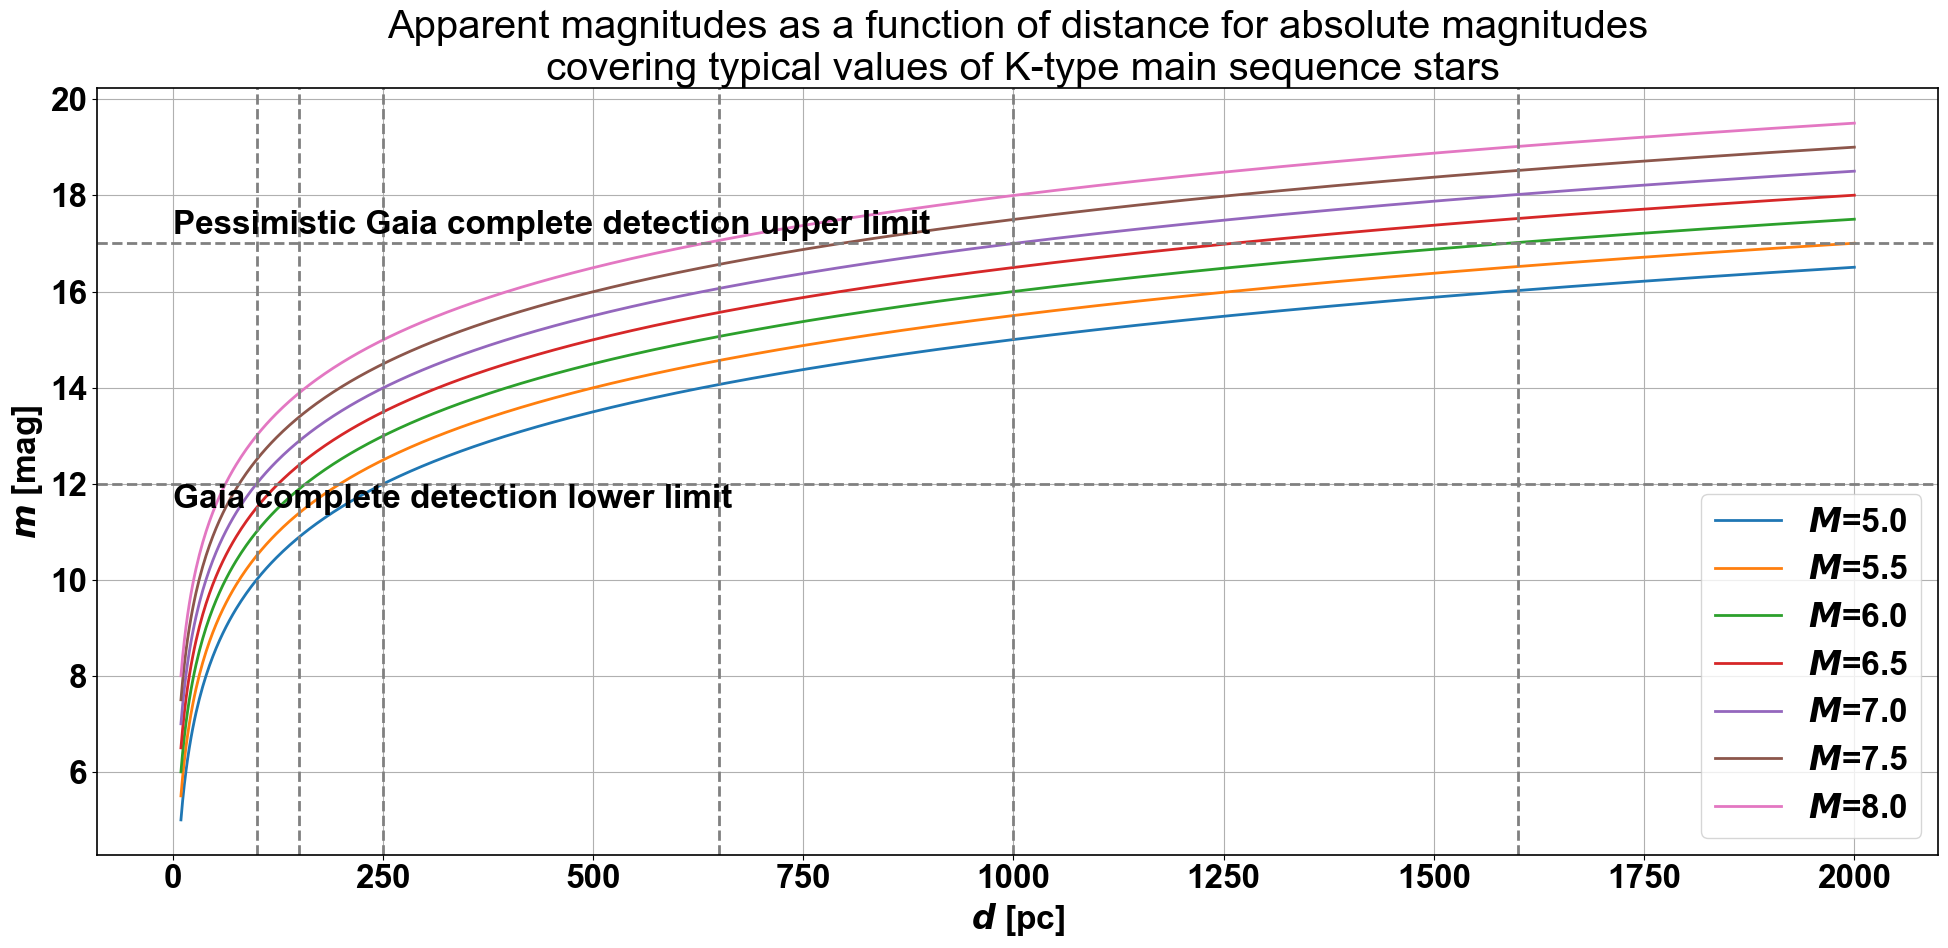

In [3]:
def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m

fig = plt.figure(figsize=(20,10))
Ms = np.linspace(5, 8, 7) # absolute magnitude in mag
dist = np.linspace(10, 2000, 1000) # pc
for M in Ms:
    m = M_d_to_m(M, dist)
    plt.plot(dist, m, label=r"$M$={:.2}".format(M))

plt.axhline(17.0, color="gray", ls="--")
plt.axhline(12.0, color="gray", ls="--")
plt.axvline(650, color="gray", ls="--")
plt.axvline(1000, color="gray", ls="--")
plt.axvline(1600, color="gray", ls="--")
plt.axvline(100, color="gray", ls="--")
plt.axvline(150, color="gray", ls="--")
plt.axvline(250, color="gray", ls="--")

plt.text(0, 17.2, "Pessimistic Gaia complete detection upper limit")
plt.text(0, 11.5, "Gaia complete detection lower limit")

plt.ylabel(r"$m$ [mag]")
plt.xlabel(r"$d$ [pc]")
plt.title("Apparent magnitudes as a function of distance for absolute magnitudes\n covering typical values of K-type main sequence stars")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("../Plots/data_old/Distance_vs_apparent_magnitude.png")
fig.set_dpi(40)
plt.show()
# See also https://gea.esac.esa.int/archive/documentation/GDR3/Catalogue_consolidation/chap_cu9val/sec_cu9val_introduction/ssec_cu9val_intro_completeness.html
# and links therein
# Fig.14.38 suggests that most of the persumably missed stars originiate from a mismodelled disc and high latitudes are fine (-> perhaps we can go higher than 17 mag)
# Though, I would not trust this hope. Perhaps it would be best to split the dataset into two or three (e.g. like this):
    # M=5-6 and d<2000pc
    # M=6-8 and d<1000pc

    #safe intervals:    M=5-6, d=250-1600
    #                   M=6-7, d=150-1000
    #                   M=7-8, d=100-650


### z dependence of stars with inaccurate parallaxe measurment

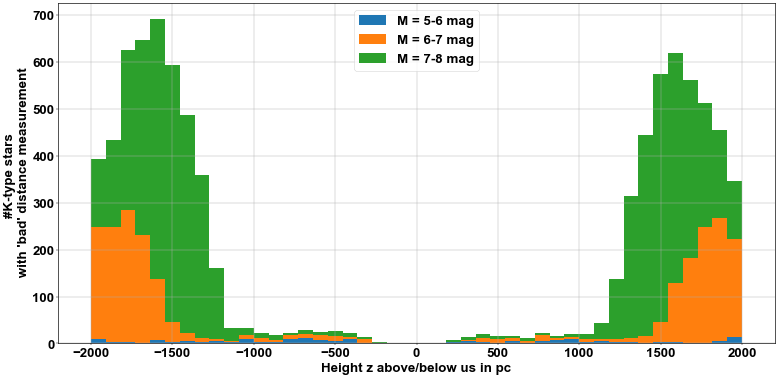

Requirement: parallax/standarterror(parallax) is larger than 5. This ensures useful parallax measurment. Removes an additional 1.17e+04 sources
We are left with 6.33e+05 sources


In [ ]:
# Distance
deg2rad = np.pi/180.
dist_pc = 1000./tab["parallax"] # in pc
# Absolute magnitude
apparent_magnitude = np.array(tab["phot_g_mean_mag"]) # 3.15 - 19.00
absolute_magnitude = apparent_magnitude - 5.*np.log10(dist_pc) + 5

parallax_over_error = np.array(tab["parallax"]/tab["parallax_error"])
min = 5
mask0 = parallax_over_error > min
group1 = (absolute_magnitude[~mask0] >= 5) & (absolute_magnitude[~mask0] < 6)
group2 = (absolute_magnitude[~mask0] >= 6) & (absolute_magnitude[~mask0] < 7)
group3 = (absolute_magnitude[~mask0] >= 7) & (absolute_magnitude[~mask0] <= 8)
z_out = (dist_pc*np.sin(tab["b"]*deg2rad))[~mask0]
absolute_magnitude_out = absolute_magnitude[~mask0]

fig = plt.figure(figsize=(20,10))
plt.hist([z_out[group1], z_out[group2], z_out[group3]], bins=44, stacked=True, range=(-2000, 2000), label=["M = 5-6 mag", "M = 6-7 mag", "M = 7-8 mag"])
plt.xlabel("Height z above/below us in pc")
plt.ylabel("#K-type stars \n with 'bad' distance measurement")
plt.grid()
plt.tight_layout()
plt.legend()
plt.savefig("../Plots/data_old/Height_distribution_bad_distance_measurement.png")
fig.set_dpi(40)
plt.show()

print("Requirement: parallax/standarterror(parallax) is larger than {}. This ensures useful parallax measurment. Removes an additional {:.2e} sources".format(min, np.nansum(~mask0)))
print("We are left with {:.2e} sources".format(np.nansum(mask0)))

#### Selecting a subsample

In [ ]:
def filtration(am_min = 5.0, am_max = 8.0):
# make this smaller for better volume completeness (default 8.0)

    # Cylinder symmetrical around galactic plane
    height = 1800. # pc
    mask1 = (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)<height-14.5) & (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)>-height-14.5)
    print("Requirement: Inside the cylinder of 2 * {} pc hight (centered at galactic plane!). Removes an additional {:.2e} sources".format(height, np.nansum(~mask1)))
    print("We are left with {:.2e} sources".format(np.nansum(mask1)))

    # Absolute magnitude limits
    mask2 = (absolute_magnitude[mask0]>=am_min) & (absolute_magnitude[mask0]<=am_max)
    print("Requirement: Absolute magnitude between {} and {}. Removes an additional {:.2e} sources".format(am_min, am_max, np.nansum(~mask2&mask1)))
    print("We are left with {:.2e} sources".format(np.nansum(mask1&mask2)))

    # Cylinder with radius r_cyl
    r_cyl = 200. # pc # parallax > cos(lat)*5
    mask3 = dist_pc[mask0] * np.cos(tab["b"][mask0]*deg2rad) < r_cyl # 200 pc cylinder 
    print("Requirement: Inside the cylinder of {} pc radius. Removes an additional {:.2e} sources".format(r_cyl, np.nansum(~mask3&mask1&mask2)))
    print("We are left with {:.2e} sources".format(np.nansum(mask1&mask2&mask3)))

    tab_filtered = tab[mask0][mask1&mask2&mask3]

    return tab_filtered

In [ ]:
# Load into separate numpy arrays
def arrays(tab_filtered):
    np_arr = np.array(tab_filtered)

    l_np = np_arr["l"]
    b_np = np_arr["b"]
    ra_np = np_arr["ra"]
    ra_error_np = np_arr["ra_error"]
    dec_np = np_arr["dec"]
    dec_error_np = np_arr["dec_error"]
    parallax_np = np_arr["parallax"]
    parallax_error_np = np_arr["parallax_error"]
    pmra_np = np_arr["pmra"]
    pmra_error_np = np_arr["pmra_error"]
    pmdec_np = np_arr["pmdec"]
    pmdec_error_np = np_arr["pmdec_error"]
    phot_g_mean_mag_np = np_arr["phot_g_mean_mag"]
    teff_gspphot_np = np_arr["teff_gspphot"]
    bp_rp_np = np_arr["bp_rp"]
    radial_velocity_np = np_arr["radial_velocity"]
    radial_velocity_error_np = np_arr["radial_velocity_error"]

    del np_arr

    return l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np

# Vertical Distribution and Velocity Dispersion

In [ ]:
###  Functions for computing the vertical velocity
def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def pm_eq_to_pm_gal(mu_alpha_cos_delta, mu_delta, alpha, delta):
    ''' In- and Output in degrees per arbitrary unit of time'''
    # from https://arxiv.org/pdf/1306.2945
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    _delta = delta * deg2rad
    _alpha = alpha * deg2rad
    C1 = np.sin(deltaG)*np.cos(_delta) - np.cos(deltaG)*np.sin(_delta)*np.cos(_alpha-alphaG)
    C2 = np.cos(deltaG)*np.sin(_alpha-alphaG)
    cos_b = np.sqrt(C1**2 + C2**2)
    mu_l_cos_b = (C1*mu_alpha_cos_delta + C2*mu_delta)/cos_b
    mu_b = (-C2*mu_alpha_cos_delta + C1*mu_delta)/cos_b
    return mu_l_cos_b, mu_b

def ra_dec_to_l_b(ra, dec):
    '''From ra and dec in degrees to l and b in degrees'''
    # See http://www.iausofa.org/2023_1011_C/sofa/icrs2g.c
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    l_ANGE = 32.93192 * deg2rad
    _ra = ra * deg2rad
    _dec = dec * deg2rad
    
    b = np.arcsin(np.cos(_dec)*np.cos(deltaG)*np.cos(_ra-alphaG)+np.sin(_dec)*np.sin(deltaG))
    x = np.sin(_ra-alphaG)*np.cos(_dec)
    y = np.sin(_dec)*np.cos(deltaG)-np.cos(_dec)*np.sin(deltaG)*np.cos(_ra-alphaG)
    
    l = np.arctan2(y, x) + l_ANGE
    l = np.mod(l, 2.*np.pi)
    
    return l/deg2rad, b/deg2rad

def compute_vz(plx, ra, dec, vlos, pm_ra, pm_dec,):
    """From 
    parallax in mas,
    ra and dec in degrees,
    vlos in km/s,
    pm_ra and pm_dec in mas/yr,
    to vz in km/s"""
    deg2rad = np.pi / 180.
    yr_to_sec = 3.154e7
    pc_to_km = 3.086e13
    mas_to_deg = 1./60./60./1000.
    _pm_ra = pm_ra * mas_to_deg # deg/yr
    _pm_dec = pm_dec * mas_to_deg # deg/yr
    
    pm_l, pm_b = pm_eq_to_pm_gal(_pm_ra, _pm_dec, ra, dec)  # deg/yr
    pm_l *=  deg2rad / yr_to_sec # rad/s
    pm_b *= deg2rad / yr_to_sec # rad/s

    l, b = ra_dec_to_l_b(ra, dec) # deg
    l *= deg2rad # rad
    b *= deg2rad # rad

    r = r_from_plx(plx) * pc_to_km  # km
    v_z = vlos * np.sin(b) + r * np.cos(b) * pm_b  # km/s
    
    return v_z

# Velocity Dispersion

Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 6.81e+02 sources
We are left with 6.32e+05 sources
Requirement: Absolute magnitude between 5.0 and 7.0. Removes an additional 3.35e+05 sources
We are left with 2.97e+05 sources
Requirement: Inside the cylinder of 200.0 pc radius. Removes an additional 0.00e+00 sources
We are left with 2.97e+05 sources
436.45272237022095 956941.422361639


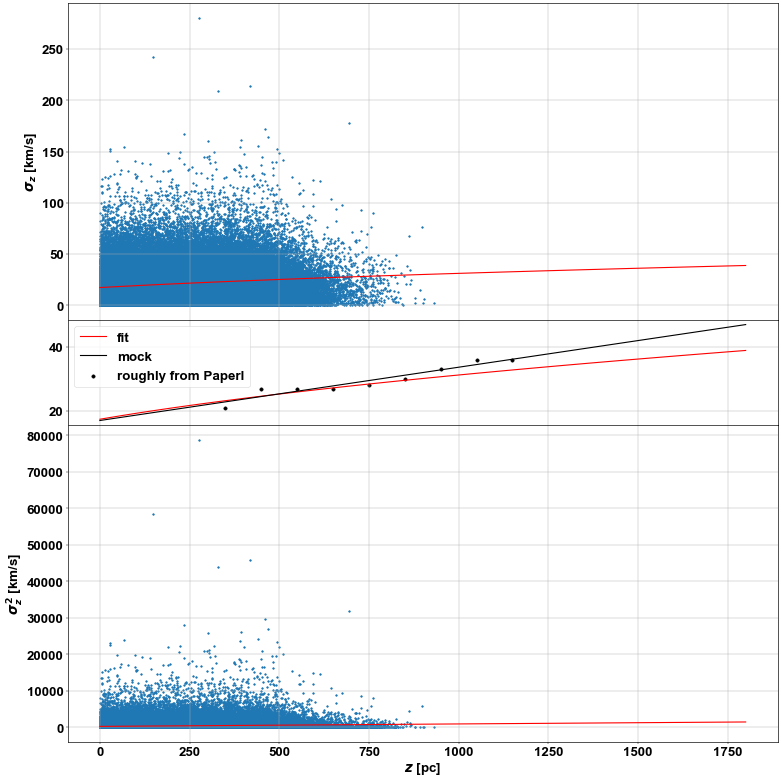

In [ ]:
am_min = 5.0
am_max = 7.0
tab_filtered = filtration(am_min, am_max)
l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

r_np = r_from_plx(parallax_np)
z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane




# fig, ax = plt.subplots(3,1, sharex=True, figsize=(20,10))
# isfin1 = np.isfinite( radial_velocity_np)
# ax[0].scatter(z_np[isfin1], radial_velocity_np[isfin1], marker='.')
# ax[0].set_ylabel(r"radial velocity [km/s]")
# ax[0].grid()
# isfin2 = np.isfinite(pmra_np)
# ax[1].scatter(z_np[isfin2], pmra_np[isfin2], marker='.')
# ax[1].set_ylabel(r"pmra [mas/yr]")
# ax[1].grid()
# isfin3 = np.isfinite(pmdec_np)
# ax[2].scatter(z_np[isfin3], pmdec_np[isfin3], marker='.')
# ax[2].set_ylabel(r"pmdec [mas/yr]")
# ax[2].grid()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)
# fig.set_dpi(40)
# plt.show()



# Compute vertical velocity dispersion
vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
hasv = np.isfinite(vz) 
vmean = np.mean(vz[hasv])
#print("Mean vertical velocity = ", vmean, "km/s")
v2 = (vz[hasv]-vmean)**2
print(np.mean(v2), np.var(v2))

# Lets fit a simple curve
POLYNOME_ORDER = 1
v2_fit = np.poly1d(np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER))
zs = np.linspace(0, 1800, 100)
sigmas = np.sqrt(v2_fit(zs))

z_vel = np.array([350, 450, 550, 650, 750, 850, 950, 1050, 1150])
s_vel = np.array([21., 27., 27., 27., 28., 30., 33., 36., 36.])

fig, ax = plt.subplots(3,1, figsize=(20,20), sharex=True, gridspec_kw={'height_ratios': [3,1, 3]})
ax[0].scatter(np.abs(z_np)[hasv], np.sqrt(v2), marker='.')
ax[0].plot(zs, sigmas, color='r')
ax[0].set_ylabel(r"$\sigma_z$ [km/s]")
ax[0].grid()
ax[1].plot(zs, sigmas, color='r', label='fit')
ax[1].plot(zs, 17. + 20/1200 * zs, color='black', label='mock')
ax[1].scatter(z_vel, s_vel, color='black', label='roughly from PaperI')
ax[1].grid()
ax[1].legend()
ax[2].set_xlabel(r"$z$ [pc]")
ax[2].scatter(np.abs(z_np)[hasv], v2, marker='.')
ax[2].plot(zs, sigmas**2, color='r')
ax[2].set_ylabel(r"$\sigma_z^2$ [km/s]")
ax[2].grid()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
fig.set_dpi(40)
plt.show()

df = pd.DataFrame({'z': z_np[hasv], 'v2': v2})

# Create a text file
df.to_csv(f'../real data/v2_{am_min:.0f}{am_max:.0f}.txt', index=False, sep=',', header=True)
np.savetxt(f'../real data/poly_{am_min:.0f}{am_max:.0f}.txt', np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER), fmt='%f')

Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 6.81e+02 sources
We are left with 6.32e+05 sources
Requirement: Absolute magnitude between 5 and 6. Removes an additional 5.87e+05 sources
We are left with 4.52e+04 sources
Requirement: Inside the cylinder of 200.0 pc radius. Removes an additional 0.00e+00 sources
We are left with 4.52e+04 sources
Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 6.81e+02 sources
We are left with 6.32e+05 sources
Requirement: Absolute magnitude between 6 and 7. Removes an additional 3.80e+05 sources
We are left with 2.52e+05 sources
Requirement: Inside the cylinder of 200.0 pc radius. Removes an additional 0.00e+00 sources
We are left with 2.52e+05 sources
Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 6.81e+02 sources
We are left with 6.32e+05 sources
Requirement: Absolute ma

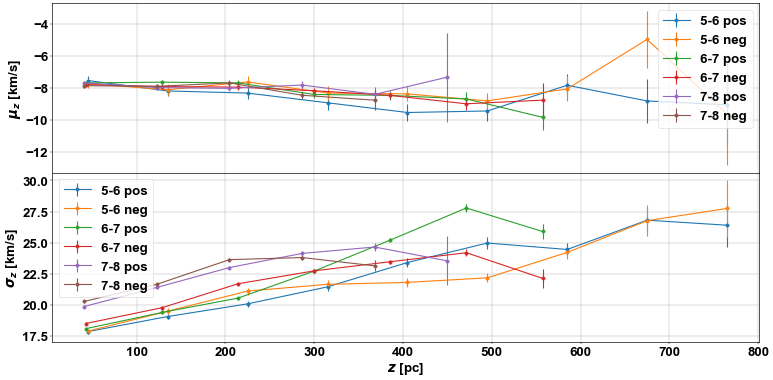

In [ ]:
def vel_disp(am_min, am_max, n_bins):

    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

    # Compute vertical velocity dispersion
    vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    hasv = np.isfinite(vz)
    vz = vz[hasv]
    z_np = z_np[hasv]

    bins = np.linspace(-1800, 1800, n_bins+1)
    vz_means = np.array([])
    vz_stds = np.array([])
    evz_means = np.array([])
    evz_stds = np.array([])
    for i in range(len(bins)-1):
        mask = (z_np >= bins[i]) & (z_np < bins[i+1])
        if sum(mask) >= 70:
            vz_means = np.append(vz_means, np.mean(vz[mask]))
            vz_stds = np.append(vz_stds, np.std(vz[mask], ddof=1))
            evz_means = np.append(evz_means, np.std(vz[mask], ddof=1)/np.sqrt(np.sum(mask)))
            evz_stds = np.append(evz_stds, np.std(vz[mask], ddof=1)/np.sqrt(2*(np.sum(mask)-1)))
        else:
            vz_means = np.append(vz_means, np.nan)
            vz_stds = np.append(vz_stds, np.nan)
            evz_means = np.append(evz_means, np.nan)
            evz_stds = np.append(evz_stds, np.nan)
    
    z = (bins[1:]+bins[:-1])/2
    i = np.isnan(vz_stds)

    return vz_means[~i], vz_stds[~i], evz_means[~i], evz_stds[~i], z[~i]

cf = pd.read_csv('../Müll/real data test/cf_56_v2_.csv', header=None).iloc[:,2]
cf_ = pd.read_csv('../Müll/real data test/cf_56_v2__.csv', header=None).iloc[:,4]
cf1 = np.exp(np.array([float(el) for el in cf[0].strip('[]').split()]))
cf2 = np.exp(np.array([float(el) for el in cf[1].strip('[]').split()]))
cf3 = np.exp(np.array([float(el) for el in cf[2].strip('[]').split()]))
cf4 = np.array([float(el) for el in cf_[0].strip('[]').split()])
cf5 = np.array([float(el) for el in cf_[1].strip('[]').split()])
cf6 = np.array([float(el) for el in cf_[2].strip('[]').split()])
cf7 = np.array([float(el) for el in cf_[3].strip('[]').split()])
cf8 = np.array([float(el) for el in cf_[4].strip('[]').split()])


fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True)
for am, n_bin in zip([[5,6], [6,7], [7,8]], [40, 42, 44]):
    vz_means, vz_stds, evz_means, evz_stds, z= vel_disp(am[0], am[1], n_bin)
    pos = np.where(z>=0)
    neg = np.where(z<0)
    ax[0].errorbar(z[pos], vz_means[pos], yerr=evz_means[pos], marker='o',label=f"{am[0]}-{am[1]} pos")
    ax[0].errorbar(abs(z[neg]), vz_means[neg], yerr=evz_means[neg], marker='o',label=f"{am[0]}-{am[1]} neg")
    ax[1].errorbar(z[pos], vz_stds[pos], yerr=evz_stds[pos], marker='o', label=f"{am[0]}-{am[1]} pos")
    ax[1].errorbar(abs(z[neg]), vz_stds[neg], yerr=evz_stds[neg], marker='o', label=f"{am[0]}-{am[1]} neg")
# ax[1].plot(np.linspace(0, 1260, 1261), np.sqrt(cf1), label='nifty1')
# ax[1].plot(np.linspace(0, 1080, 1081), np.sqrt(cf2), label='nifty2')
# ax[1].plot(np.linspace(0, 1620, 1621), np.sqrt(cf3), label='nifty3')
# ax[1].plot(np.linspace(0, 1620, 1621), np.sqrt(cf4), label='nifty4')
# ax[1].plot(np.linspace(0, 1800, 1801), np.sqrt(cf5), label='nifty5')
# ax[1].plot(np.linspace(0, 1800, 1801), np.sqrt(cf6), label='nifty6')
# ax[1].plot(np.linspace(0, 1800, 1801), np.sqrt(cf7), label='nifty7')
# ax[1].plot(np.linspace(0, 1260, 1261), np.sqrt(cf8), label='nifty8')
ax[0].set_xlabel(r"$z$ [pc]")
ax[0].set_ylabel(r"$\mu_z$ [km/s]")
ax[0].grid()
ax[0].legend()
ax[1].set_xlabel(r"$z$ [pc]")
ax[1].set_ylabel(r"$\sigma_z$ [km/s]")
ax[1].grid()
ax[1].legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig("../Plots/data_old/Vertical_velocity_dispersion_comparison.png")
fig.set_dpi(40)
plt.show()



In [ ]:
def Verarbeitung(am_min, am_max, n_bin, range, Plot):
    # Histogram in z
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane
    
    fig = plt.figure(figsize=(20,10))
    n, bins, _ = plt.hist(z_np, bins=n_bin, range=(-range, range))
    plt.yscale("log")
    plt.xlabel("Height z above/below us in pc")
    plt.ylabel("#K-type stars")
    plt.grid(which='both')
    fig.set_dpi(40)

    if Plot:
        plt.show()

    else:
        plt.close()

    # Create a text file
    np.savetxt(f'../real data/n_{am_min:.0f}{am_max:.0f}.txt', n, fmt='%i')
    np.savetxt(f'../real data/bins_{am_min:.0f}{am_max:.0f}.txt', bins, fmt='%f')

Verarbeitung(5.0, 6.0, 40, 1800, False)
Verarbeitung(6.0, 7.0, 120, 1800, False)
Verarbeitung(5.0, 7.0, 120, 1800, False)
Verarbeitung(7.0, 8.0, 96, 1440, False)
Verarbeitung(5.0, 8.0, 200, 1800, False)
# Verarbeitung(5.0, 7.0, 120, 1200, True)


Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 6.81e+02 sources
We are left with 6.32e+05 sources
Requirement: Absolute magnitude between 5.0 and 6.0. Removes an additional 5.87e+05 sources
We are left with 4.52e+04 sources
Requirement: Inside the cylinder of 200.0 pc radius. Removes an additional 0.00e+00 sources
We are left with 4.52e+04 sources
Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 6.81e+02 sources
We are left with 6.32e+05 sources
Requirement: Absolute magnitude between 6.0 and 7.0. Removes an additional 3.80e+05 sources
We are left with 2.52e+05 sources
Requirement: Inside the cylinder of 200.0 pc radius. Removes an additional 0.00e+00 sources
We are left with 2.52e+05 sources
Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 6.81e+02 sources
We are left with 6.32e+05 sources
Requirement: Abs

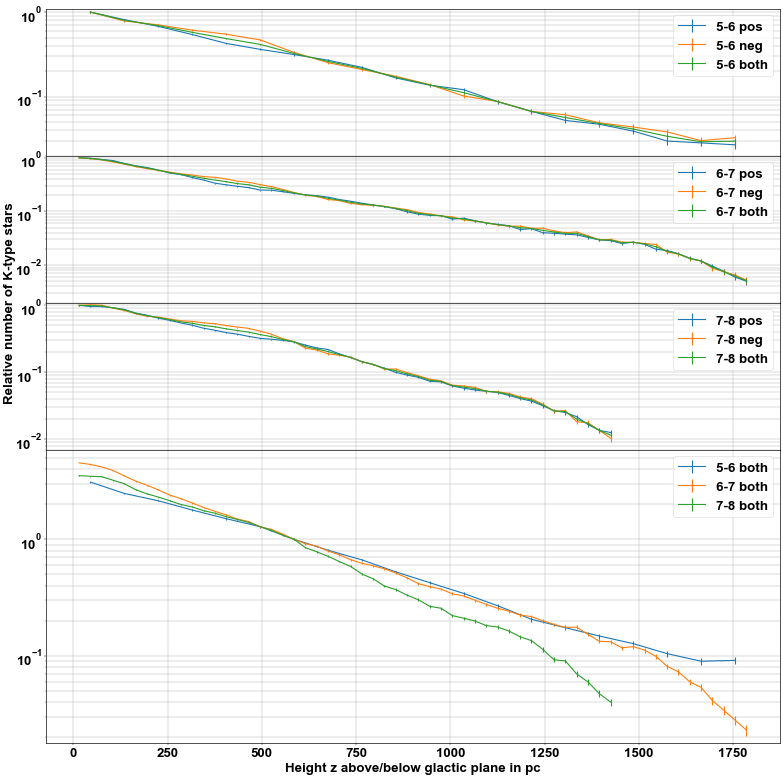

In [ ]:
''' real data'''
n_real = np.loadtxt('../real data/n_56.txt')
bins = np.loadtxt('../real data/bins_56.txt')
zz_real = (bins[1:]+bins[:-1])/2
pos = np.where(zz_real >= 0)
neg = np.where(zz_real < 0)
n_sum = (n_real[pos]+np.flip(n_real[neg]))

n_real_67 = np.loadtxt('../real data/n_67.txt')
bins_67 = np.loadtxt('../real data/bins_67.txt')
zz_real_67 = (bins_67[1:]+bins_67[:-1])/2
pos_67 = np.where(zz_real_67 >= 0)
neg_67 = np.where(zz_real_67 < 0)
n_sum_67 = (n_real_67[pos_67]+np.flip(n_real_67[neg_67]))

n_real_78 = np.loadtxt('../real data/n_78.txt')
bins_78 = np.loadtxt('../real data/bins_78.txt')
zz_real_78 = (bins_78[1:]+bins_78[:-1])/2
pos_78 = np.where(zz_real_78 >= 0)
neg_78 = np.where(zz_real_78 < 0)
n_sum_78 = (n_real_78[pos_78]+np.flip(n_real_78[neg_78]))

''' visualisation'''
fig, ax = plt.subplots(4,1, figsize=(20,20), gridspec_kw={'height_ratios': [1, 1, 1, 2]}, sharex=True)
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[2].set_yscale("log")
ax[3].set_yscale("log")

ax[0].errorbar(zz_real[pos], n_real[pos]/n_real[pos][0], yerr=np.sqrt(n_real)[pos]/n_real[pos][0], label="5-6 pos")
ax[0].errorbar(abs(zz_real[neg]), n_real[neg]/n_real[neg][-1], yerr=np.sqrt(n_real)[neg]/n_real[neg][-1], label="5-6 neg")
ax[0].errorbar(zz_real[pos], n_sum/n_sum[0], yerr=np.sqrt(n_sum)/n_sum[0], label="5-6 both")

ax[1].errorbar(zz_real_67[pos_67], n_real_67[pos_67]/n_real_67[pos_67][0], yerr=np.sqrt(n_real_67)[pos_67]/n_real_67[pos_67][0], label="6-7 pos")
ax[1].errorbar(abs(zz_real_67[neg_67]), n_real_67[neg_67]/n_real_67[neg_67][-1], yerr=np.sqrt(n_real_67)[neg_67]/n_real_67[neg_67][-1], label="6-7 neg")
ax[1].errorbar(zz_real_67[pos_67], n_sum_67/n_sum_67[0], yerr=np.sqrt(n_sum_67)/n_sum_67[0], label="6-7 both")

ax[2].errorbar(zz_real_78[pos_78], n_real_78[pos_78]/n_real_78[pos_78][0], yerr=np.sqrt(n_real_78)[pos_78]/n_real_78[pos_78][0], label="7-8 pos")
ax[2].errorbar(abs(zz_real_78[neg_78]), n_real_78[neg_78]/n_real_78[neg_78][-1], yerr=np.sqrt(n_real_78)[neg_78]/n_real_78[neg_78][-1], label="7-8 neg")
ax[2].errorbar(zz_real_78[pos_78], n_sum_78/n_sum_78[0], yerr=np.sqrt(n_sum_78)/n_sum_78[0], label="7-8 both")

ax[3].errorbar(zz_real[pos], n_sum/n_sum[6], yerr=np.sqrt(n_sum)/n_sum[6], label="5-6 both")
ax[3].errorbar(zz_real_67[pos_67], n_sum_67/n_sum_67[19], yerr=np.sqrt(n_sum_67)/n_sum_67[19], label="6-7 both")
ax[3].errorbar(zz_real_78[pos_78], n_sum_78/n_sum_78[19], yerr=np.sqrt(n_sum_78)/n_sum_78[19], label="7-8 both")

ax[3].set_xlabel("Height z above/below glactic plane in pc")
ax[0].set_ylabel("Relative number of K-type stars")
ax[0].yaxis.set_label_coords(-0.04, -1)

ax[0].grid(which='both')
ax[0].legend()
ax[1].grid(which='both')
ax[1].legend()
ax[2].grid(which='both')
ax[2].legend()
ax[3].grid(which='both')
ax[3].legend()

ax[0].set_ylim(2e-2, 1.1)
ax[1].set_ylim(2e-3, 1.1)
ax[2].set_ylim(7e-3, 1.1)

plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig("../Plots/data_old/Height_distribution_real_data_comparison.png")
fig.set_dpi(40)
plt.show()
